1. DATA EXPLORATION 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

A.Dataset overview 

In [3]:
df = pd.read_csv("property_price_data.csv")
print("DATASET OVERVIEW")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nSummary statistics (numeric):")
print(df.describe())


DATASET OVERVIEW
Shape: (970, 69)
Columns: 69

Data types:
object     40
int64      27
float64     2
Name: count, dtype: int64

First 5 rows:
   Prop_Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   PRO504          20       RL        100.0    15537   Pave   NaN      IR1   
1   PRO102          60       RL         77.0     9534   Pave   NaN      Reg   
2   PRO609          70       RL          NaN    12781   Pave   NaN      Reg   
3  PRO1090         120       FV         37.0     3728   Pave  Pave      IR1   
4   PRO820         120       RL         44.0     6606   Pave   NaN      IR1   

  LandContour Utilities  ... 3SsnPorch ScreenPorch PoolArea PoolQC Fence  \
0         Lvl    AllPub  ...         0         161        0    NaN  GdWo   
1         Lvl    AllPub  ...         0           0        0    NaN   NaN   
2         HLS    AllPub  ...         0           0        0    NaN   NaN   
3         Lvl    AllPub  ...         0           0        0    NaN   NaN   
4  

B.Missing data analysis


MISSING DATA ANALYSIS
             Missing_Count  Missing_Percent
PoolQC                 963        99.278351
MiscFeature            941        97.010309
Alley                  914        94.226804
Fence                  801        82.577320
FireplaceQu            437        45.051546
LotFrontage            181        18.659794
GarageQual              52         5.360825
GarageYrBlt             52         5.360825
GarageType              52         5.360825
GarageCond              52         5.360825


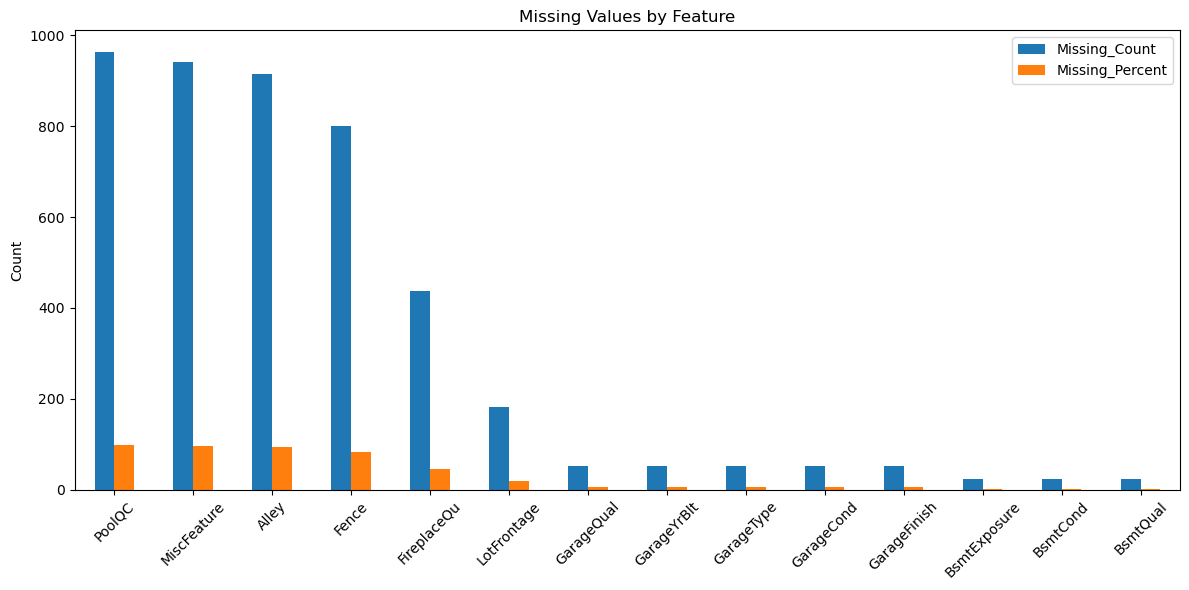

In [4]:
print("\nMISSING DATA ANALYSIS")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent': missing_percent
}).sort_values('Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0].head(10))
missing_df[missing_df['Missing_Count'] > 0].plot(kind='bar', figsize=(12,6))
plt.title('Missing Values by Feature')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C. Target variable analysis



TARGET VARIABLE ANALYSIS (SalePrice)
count       970.000000
mean     184272.595876
std       82061.647461
min       35336.000000
25%      132225.000000
50%      165641.500000
75%      215268.250000
max      758639.000000
Name: SalePrice, dtype: float64


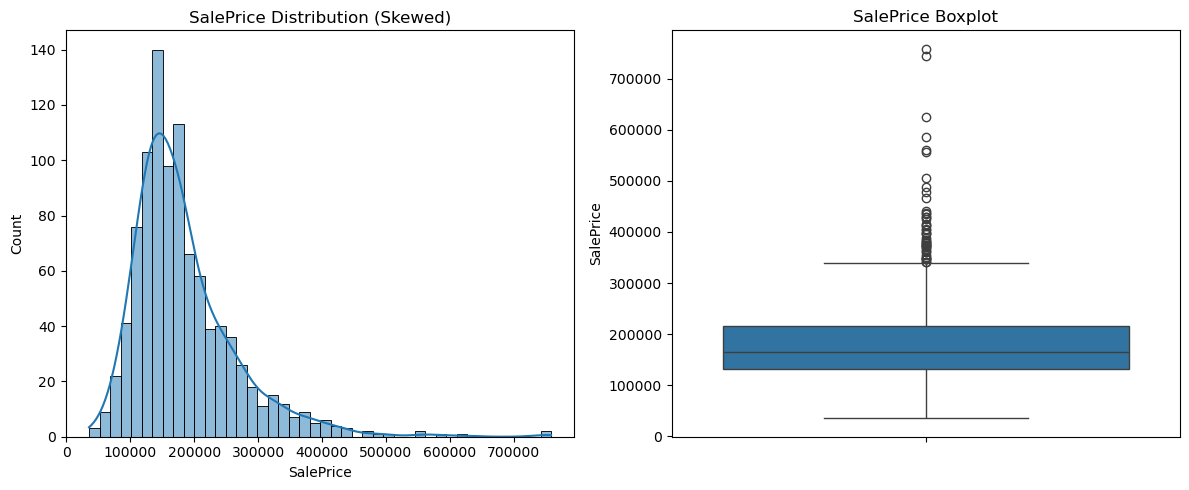

In [5]:
print("\nTARGET VARIABLE ANALYSIS (SalePrice)")
print(df['SalePrice'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution (Skewed)')
# Boxplot
sns.boxplot(y=df['SalePrice'], ax=axes[1])
axes[1].set_title('SalePrice Boxplot')
plt.tight_layout()
plt.show()


D. Feature correlation analysis


FEATURE CORRELATION ANALYSIS
Top 10 correlations with SalePrice:
SalePrice       1.000000
OverallQual     0.787500
GrLivArea       0.705701
GarageCars      0.642999
GarageArea      0.619476
TotalBsmtSF     0.597116
FullBath        0.574070
TotRmsAbvGrd    0.520046
YearBuilt       0.511482
YearRemodAdd    0.486579
Name: SalePrice, dtype: float64


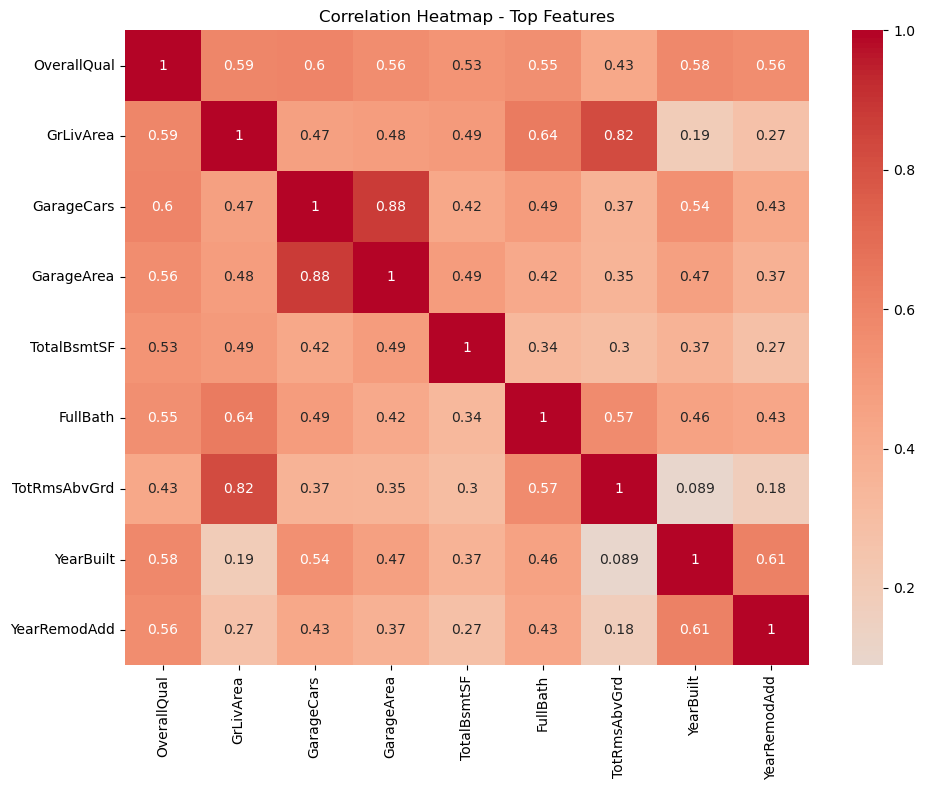

In [6]:
print("\nFEATURE CORRELATION ANALYSIS")
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
top_correlations = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(10)

print("Top 10 correlations with SalePrice:")
print(top_correlations)

plt.figure(figsize=(10, 8))
top_corr_features = top_correlations.index[1:11]  # Exclude SalePrice itself
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.show()


2. DATA PREPROCESSING

A. Missing value treatment

In [7]:
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

df_processed = df.copy()

df_processed.drop('Prop_Id', axis=1, inplace=True)

print("MISSING VALUE TREATMENT")

no_feature_cols = ['PoolQC', 'Alley', 'Fence', 'MiscFeature', 'FireplaceQu',
                   'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                   'BsmtQual', 'BsmtCond', 'BsmtExposure']
for col in no_feature_cols:
    if col in df_processed.columns:
        df_processed[col].fillna('None', inplace=True)
        print(f"{col}: Filled with 'None'")


if 'LotFrontage' in df_processed.columns:
    df_processed['LotFrontage'] = df_processed.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))
    print("LotFrontage: Neighborhood median")


mode_cols = ['Electrical', 'KitchenQual', 'Functional', 'Exterior1st', 'Exterior2nd', 
             'SaleType', 'MSZoning', 'Utilities']
for col in mode_cols:
    if col in df_processed.columns:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
        print(f"{col}: Mode fill")

print(f"\nMissing values remaining: {df_processed.isnull().sum().sum()}")



DATA PREPROCESSING
MISSING VALUE TREATMENT
PoolQC: Filled with 'None'
Alley: Filled with 'None'
Fence: Filled with 'None'
MiscFeature: Filled with 'None'
FireplaceQu: Filled with 'None'
GarageType: Filled with 'None'
GarageFinish: Filled with 'None'
GarageQual: Filled with 'None'
GarageCond: Filled with 'None'
BsmtQual: Filled with 'None'
BsmtCond: Filled with 'None'
BsmtExposure: Filled with 'None'
LotFrontage: Neighborhood median
Electrical: Mode fill
KitchenQual: Mode fill
Functional: Mode fill
Exterior1st: Mode fill
Exterior2nd: Mode fill
MSZoning: Mode fill
Utilities: Mode fill

Missing values remaining: 52


B Outlier detection & handling

In [8]:
print("\nOUTLIER DETECTION & HANDLING")

def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)].shape[0]

outlier_counts = {}
for col in ['GrLivArea', 'LotArea', 'SalePrice']:
    if col in df_processed.columns:
        outlier_counts[col] = detect_outliers(df_processed, col)

print("Outliers detected:")
for col, count in outlier_counts.items():
    print(f"  {col}: {count} outliers")

initial_rows = len(df_processed)
df_processed = df_processed[(df_processed['GrLivArea'] < 4000) | 
                           (df_processed['OverallQual'] > 4)]
print(f"Rows after outlier removal: {len(df_processed)} (removed {initial_rows - len(df_processed)})")



OUTLIER DETECTION & HANDLING
Outliers detected:
  GrLivArea: 25 outliers
  LotArea: 43 outliers
  SalePrice: 47 outliers
Rows after outlier removal: 970 (removed 0)


C. Data type conversions

In [9]:
print("\nDATA TYPE CONVERSIONS")
object_cols = df_processed.select_dtypes(include=['object']).columns
for col in object_cols:
    df_processed[col] = df_processed[col].astype('category')

print("Data types after conversion:")
print(df_processed.dtypes.value_counts())



DATA TYPE CONVERSIONS
Data types after conversion:
int64       27
category     3
category     3
float64      2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


D. Data quality validation

In [10]:
print("\nDATA QUALITY VALIDATION")
print("Final shape:", df_processed.shape)
print("Missing values:", df_processed.isnull().sum().sum())
print("Duplicate rows:", df_processed.duplicated().sum())

# Range checks for key features
quality_check = {
    'OverallQual': f"{df_processed['OverallQual'].min()}-{df_processed['OverallQual'].max()} (valid 1-10)",
    'GrLivArea': f"{df_processed['GrLivArea'].min():.0f}-{df_processed['GrLivArea'].max():.0f} sqft",
    'SalePrice': f"${df_processed['SalePrice'].min():,.0f}-${df_processed['SalePrice'].max():,.0f}"
}
print("\nQuality checks:")
for feature, status in quality_check.items():
    print(f"  {feature}: {status}")



DATA QUALITY VALIDATION
Final shape: (970, 68)
Missing values: 52
Duplicate rows: 0

Quality checks:
  OverallQual: 1-10 (valid 1-10)
  GrLivArea: 438-5642 sqft
  SalePrice: $35,336-$758,639


3. FEATURE ENGINEERING

A. Target variable transformation


FEATURE ENGINEERING


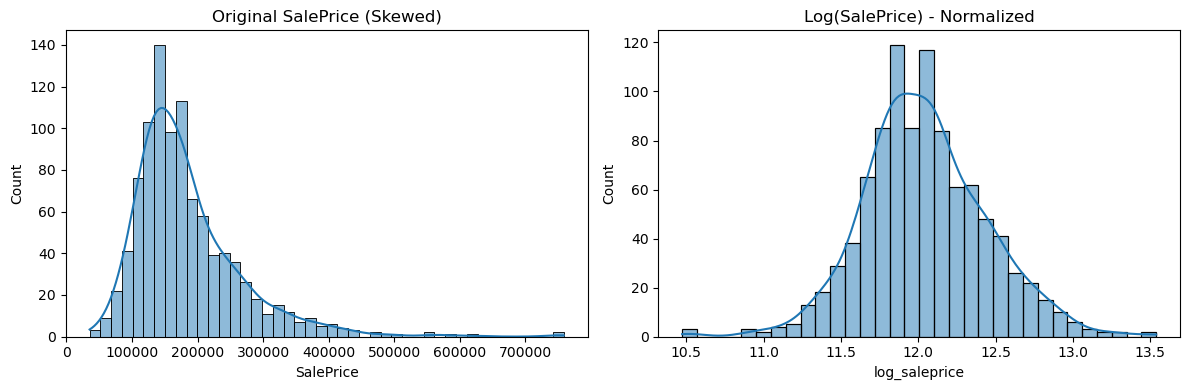

In [11]:
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)

df_engineered = df_processed.copy()
df_engineered['log_saleprice'] = np.log1p(df_engineered['SalePrice'])

# Visualize transformation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_engineered['SalePrice'], kde=True)
plt.title('Original SalePrice (Skewed)')

plt.subplot(1, 2, 2)
sns.histplot(df_engineered['log_saleprice'], kde=True)
plt.title('Log(SalePrice) - Normalized')
plt.tight_layout()
plt.show()


B. Categorical encoding

In [12]:
print("\nCATEGORICAL ENCODING")
cat_cols = [col for col in df_engineered.select_dtypes(['category']).columns 
            if df_engineered[col].nunique() < 25]  # Low cardinality

print(f"Encoding {len(cat_cols)} categorical features:")
print(cat_cols[:5], "..." if len(cat_cols) > 5 else "")

df_encoded = pd.get_dummies(df_engineered, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")



CATEGORICAL ENCODING
Encoding 38 categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour'] ...
Shape after encoding: (970, 201)


C. Feature selection strategy

In [14]:
print("\nFEATURE SELECTION STRATEGY")
numeric_features = df_encoded.select_dtypes(include=[np.number])
correlation_scores = numeric_features.corr()['log_saleprice'].abs().sort_values(ascending=False)

n_features = min(50, len(correlation_scores)-1)
selected_features = correlation_scores.head(n_features + 1).index
df_final = df_encoded[selected_features]

print(f"Selected {len(selected_features)-1} features")
print("Top 5:", correlation_scores.head().index[1:6].tolist())



FEATURE SELECTION STRATEGY
Selected 29 features
Top 5: ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars']


D. Feature scaling

In [15]:
print("\nFEATURE SCALING")
feature_columns = df_final.select_dtypes(np.number).columns.drop('log_saleprice')
scaler = StandardScaler()
df_final[feature_columns] = scaler.fit_transform(df_final[feature_columns])

print("Scaling complete")
print(f"Final dataset shape: {df_final.shape}")



FEATURE SCALING
Scaling complete
Final dataset shape: (970, 30)


4. MODEL DEVELOPMENT

A. Train-test split

In [16]:
X = df_final.drop(['log_saleprice', 'SalePrice'], axis=1)
y = df_final['log_saleprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")


Train set: (776, 28), Test set: (194, 28)


B. Model selection & justification

In [17]:
print("\nMODEL SELECTION")
print("1. Linear Regression: Interpretable, works well with scaled features")
print("2. Random Forest: Handles non-linearity, feature interactions")
print("3. Ridge Regression: Prevents overfitting with regularization")

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}



MODEL SELECTION
1. Linear Regression: Interpretable, works well with scaled features
2. Random Forest: Handles non-linearity, feature interactions
3. Ridge Regression: Prevents overfitting with regularization


C. Model training & parameter tuning

In [19]:
print("Total missing values before modeling:", df_final.isna().sum().sum())

num_cols = df_final.select_dtypes(include=[np.number]).columns
cat_cols = df_final.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    df_final[col].fillna(df_final[col].median(), inplace=True)

for col in cat_cols:
    df_final[col].fillna(df_final[col].mode()[0], inplace=True)

print("Total missing values after imputation:", df_final.isna().sum().sum())


Total missing values before modeling: 52
Total missing values after imputation: 0


In [20]:
X = df_final.drop(['log_saleprice', 'SalePrice'], axis=1)
y = df_final['log_saleprice']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
print("\nMODEL TRAINING RESULTS")
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name:18}: RMSE={rmse:.4f}, R²={r2:.3f}")

best_model_name = max(results.keys(), key=lambda k: results[k]['R2'])
print(f"\nBest Model: {best_model_name}")



MODEL TRAINING RESULTS
Linear Regression : RMSE=0.1337, R²=0.889
Ridge Regression  : RMSE=0.1338, R²=0.889
Random Forest     : RMSE=0.1452, R²=0.869

Best Model: Linear Regression


5. BUSINESS INSIGHTS

A. Performance metrics calculation

In [22]:
print("\n" + "="*60)
print("EXECUTIVE SUMMARY - MODEL PERFORMANCE")
print("="*60)

best_results = results[best_model_name]
print(f"Dataset: {df.shape[0]:,} observations")
print(f"Features used: {X.shape[1]}")
print(f"Best Model: {best_model_name}")
print(f"Test R² Score: {best_results['R2']:.1%}")
print(f"Test RMSE: {best_results['RMSE']:.4f}")



EXECUTIVE SUMMARY - MODEL PERFORMANCE
Dataset: 970 observations
Features used: 28
Best Model: Linear Regression
Test R² Score: 88.9%
Test RMSE: 0.1337


B. Feature importance analysis

In [23]:
print("\nFEATURE IMPORTANCE ANALYSIS")
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(rf_importance.to_string(index=False))



FEATURE IMPORTANCE ANALYSIS
     Feature  Importance
 OverallQual    0.552902
   GrLivArea    0.107893
  GarageCars    0.076590
 TotalBsmtSF    0.065313
   YearBuilt    0.035561
  GarageArea    0.029313
     LotArea    0.021533
 OverallCond    0.015567
YearRemodAdd    0.012404
 LotFrontage    0.012225


C. Visualization

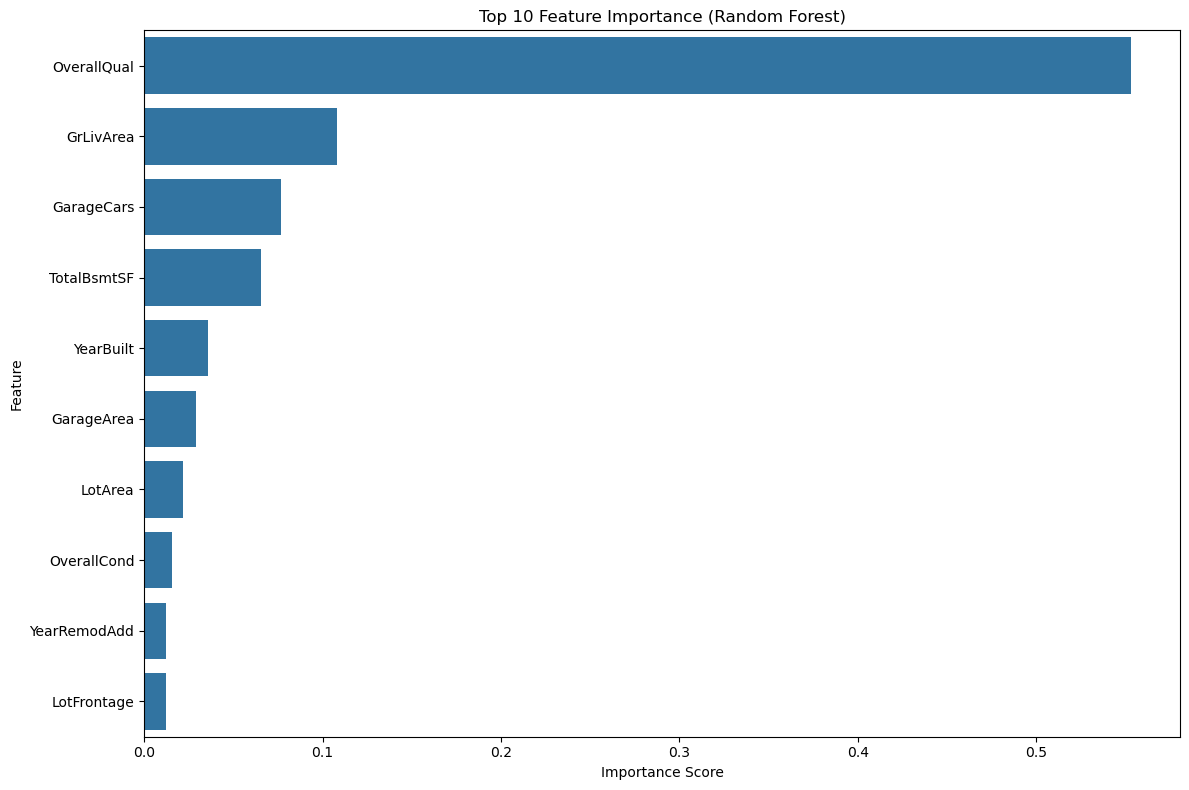

In [24]:
plt.figure(figsize=(12, 8))
sns.barplot(data=rf_importance, x='Importance', y='Feature')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


D. Business recommendations + Limitations

In [25]:
print("\nBUSINESS RECOMMENDATIONS")
print("1. Prioritize OverallQual improvements (highest impact)")
print("2. Optimize GrLivArea and garage capacity")
print("3. Target premium Neighborhood locations")
print("4. Recent remodels add significant value")

print("\nMODEL LIMITATIONS")
print("1. Geographic scope limited to Ames, IA")
print("2. Static snapshot (no time-series trends)")
print("3. Assumes linear relationships in baseline model")

print("\nFUTURE IMPROCTIONS")
print("1. Ensemble multiple models")
print("2. Add temporal market data")
print("3. External economic indicators")



BUSINESS RECOMMENDATIONS
1. Prioritize OverallQual improvements (highest impact)
2. Optimize GrLivArea and garage capacity
3. Target premium Neighborhood locations
4. Recent remodels add significant value

MODEL LIMITATIONS
1. Geographic scope limited to Ames, IA
2. Static snapshot (no time-series trends)
3. Assumes linear relationships in baseline model

FUTURE IMPROCTIONS
1. Ensemble multiple models
2. Add temporal market data
3. External economic indicators
